In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os
import cv2
from rename_dataset import rename_dataset
from alignement import process_folder
from ImageData import ImageDataset


### Rename dataset

now we have: <br>
celeb_faces/<br>
├── Brad_Pitt/<br>
│   ├── img001.jpg<br>
│   ├── img002.jpg<br>
│   ├── ...<br>
│   └── img100.jpg<br>
├── Emma_Watson/<br>
│   ├── img001.jpg<br>
│   ├── img002.jpg<br>
│   ├── ...<br>
│   └── img100.jpg<br>
└── Tom_Hanks/<br>
    ├── img001.jpg<br>
    ├── img002.jpg<br>
    ├── ...<br>
    └── img100.jpg<br>


In [2]:


base_dir = "../../data/celeb_faces"
#rename_dataset(base_dir)

### Aligned for PCA
And greyscale

In [3]:

in_dir = base_dir
out_dir = "../../data/celeb_faces_aligned"

failed = process_folder(in_dir, out_dir, grayscale_after=True, normalize_0_1=True, target_size=256, min_conf=0.85)

print(f"Failed to process {len(failed)} images:")

Processing: ../../data/celeb_faces\angelina_jolie\img00.jpg
Processing: ../../data/celeb_faces\angelina_jolie\img01.jpg
Processing: ../../data/celeb_faces\angelina_jolie\img02.jpg
Processing: ../../data/celeb_faces\angelina_jolie\img03.jpg
Processing: ../../data/celeb_faces\angelina_jolie\img04.jpg
Processing: ../../data/celeb_faces\angelina_jolie\img05.jpg
Processing: ../../data/celeb_faces\angelina_jolie\img06.jpg
Processing: ../../data/celeb_faces\angelina_jolie\img07.jpg
Processing: ../../data/celeb_faces\angelina_jolie\img08.jpg
Processing: ../../data/celeb_faces\angelina_jolie\img09.jpg
Processing: ../../data/celeb_faces\angelina_jolie\img10.jpg
Processing: ../../data/celeb_faces\angelina_jolie\img11.jpg
Processing: ../../data/celeb_faces\angelina_jolie\img12.jpg
Processing: ../../data/celeb_faces\angelina_jolie\img13.jpg
Processing: ../../data/celeb_faces\angelina_jolie\img14.jpg
Processing: ../../data/celeb_faces\angelina_jolie\img15.jpg
Processing: ../../data/celeb_faces\angel

KeyboardInterrupt: 

### Create a matrix

[<br>
        img1,<br>
    img2,<br>
    img3,<br>
    ...<br>
    imgn<br>
]

In [4]:
root_dir = "../../data/celeb_faces_aligned"

dataframe = []

for root, dirs, files in os.walk(root_dir):
    for fname in files:
        img_path = os.path.join(root, fname)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        dataframe.append(img.flatten()) # type: ignore

dataframe = np.vstack(dataframe) # vertical stack, each image is a row
print(f"Dataframe shape: {dataframe.shape}")





Dataframe shape: (1791, 65536)


### Make an object and write to file
Binary with pickle

In [5]:

data = ImageDataset(dataframe, 256, 256)
data_file = "../../data/image_matrix.pkl"
with open(data_file, "wb") as f:
    pickle.dump(data, f)

    

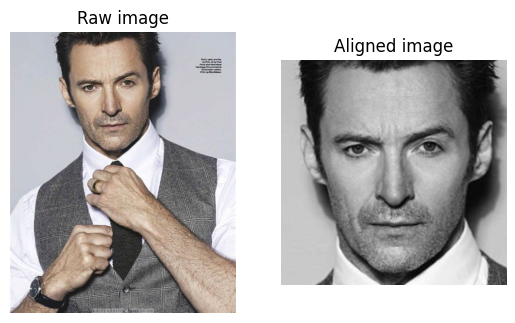

In [5]:
path_raw = "C:\\Users\\baklu\\Documents\\NTNU\\IT3212\\data\\celeb_faces\\hugh_jackman\\img42.jpg"
path_aligned = "C:\\Users\\baklu\\Documents\\NTNU\\IT3212\\data\\celeb_faces_aligned\\hugh_jackman\\img42_aligned_256.png"

plt.subplot(1, 2, 1)
img_raw = cv2.imread(path_raw)
plt.title("Raw image")
plt.imshow(cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.subplot(1, 2, 2)
img_aligned = cv2.imread(path_aligned, cv2.IMREAD_GRAYSCALE)
plt.title("Aligned image")
plt.imshow(img_aligned, cmap="gray")
plt.axis("off")
plt.show()
